### 1. Data Importing and Cleaning

In [2]:
# Importing libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [30]:
healthcare_facilities_df = pd.read_csv("C:/Users/tk_ko/Desktop/SGH/1. Hospital Admissions, Public Sector Outpatient Attendances And Day Surgery Counts.csv")
hospital_admissions_df = pd.read_csv("C:/Users/tk_ko/Desktop/SGH/2. Hospital Admission Rate by Gender and Age.csv")
risk_factor_df = pd.read_excel("C:/Users/tk_ko/Desktop/SGH/3. Prevalence of Health Indicators for SG adults.xlsx")

#### Hospital Admissions, Public Sector Outpatient Attendances and Day Surgery Counts

In [10]:
# Display the first 10 rows
healthcare_facilities_df.head(10)

,Healthcare Facilities,Admission Counts,Year,Month
0,Community Hospitals Admissions (Non-Public),na,1989,Sep
1,Psychiatric Hospitals Admissions (Non-Public),na,1993,Mar
2,Community Hospitals Admissions (Total),1609,2019,Jan
3,Polyclinics,435294,2016,Dec
4,Acute Hospitals Admissions (Public),na,1987,Jun
5,Acute Hospitals Admissions (Public),44184,2023,Aug
6,Polyclinics,478843,2017,Jun
7,Psychiatric Hospitals Admissions (Public),793,2010,Sep
8,Acute Hospitals Admissions (Public),na,1996,Oct
9,Specialist Outpatient Clinics,186011,1995,Nov


In [35]:
# Describe the info of each column
healthcare_facilities_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3948 entries, 2 to 6214
Data columns (total 4 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Healthcare Facilities  3948 non-null   object
 1   Admission Counts       3948 non-null   object
 2   Year                   3948 non-null   int64 
 3   Month                  3948 non-null   object
dtypes: int64(1), object(3)
memory usage: 154.2+ KB


In [31]:
# Exploring the range of values in every column to check unexpected or rare facility types
# All facilities have balanced number of counts with no one-off labels
healthcare_facilities_df['Healthcare Facilities'].value_counts()

Healthcare Facilities
Community Hospitals Admissions (Non-Public)      444
Psychiatric Hospitals Admissions (Non-Public)    444
Community Hospitals Admissions (Total)           444
Polyclinics                                      444
Acute Hospitals Admissions (Public)              444
Psychiatric Hospitals Admissions (Public)        444
Specialist Outpatient Clinics                    444
Dental Clinics                                   444
Accident & Emergency Departments                 444
Acute Hospitals Admissions (Non-Public)          444
Acute Hospitals Admissions (Total)               444
Day Surgeries                                    444
Psychiatric Hospitals Admissions (Total)         444
Community Hospitals Admissions (Public)          444
Name: count, dtype: int64

In [32]:
# Admission Counts is a categorical variable, thus there might be odd one-off values besides numerical counts
healthcare_facilities_df['Admission Counts'].value_counts()

Admission Counts
na       2268
0         255
707        10
791         9
697         9
         ... 
197         1
87475       1
96708       1
39926       1
31353       1
Name: count, Length: 3114, dtype: int64

In [33]:
# Find rows where Admission Counts is 'na', removing leading and trailing spaces and checking whether the cleaned value is exactly 'na'
na_mask = healthcare_facilities_df['Admission Counts'].astype(str).str.strip().eq('na')
na_rows = healthcare_facilities_df[na_mask]

# Confirm that na_rows only contain 'na'
na_rows['Admission Counts'].value_counts(dropna=False)

Admission Counts
na    2268
Name: count, dtype: int64

In [34]:
# Keep only non-na rows
healthcare_facilities_df = healthcare_facilities_df[~na_mask]

# Confirm there are no more 'na' rows
healthcare_facilities_df['Admission Counts'].astype(str).str.strip().eq('na').sum()

np.int64(0)

In [45]:
# Convert Admission Counts from object to numeric
healthcare_facilities_df['Admission Counts'] = pd.to_numeric(healthcare_facilities_df['Admission Counts'])

In [46]:
# Sanity check on Admission Counts column to check the distribution of values using describe()
# Admission Counts has a large variance, with a high maximum value of 627,174 that is still a possible value
healthcare_facilities_df['Admission Counts'].describe().T

count      3948.000000
mean      92139.220111
std      132747.562852
min           0.000000
25%         792.750000
50%       37385.500000
75%       97916.500000
max      627174.000000
Name: Admission Counts, dtype: float64

In [39]:
# Checking Year column using value_counts
healthcare_facilities_df['Year'].value_counts().sort_index()

Month
Apr     329
Aug     329
Dec     329
Feb     329
Jan     329
Jul     329
Jun     329
Mar     329
May     329
Nov     329
Oct     329
Sep     329
Name: count, dtype: int64

In [40]:
# Lastly, check Month column using value_counts
healthcare_facilities_df['Month'].value_counts().sort_index()

Month
Apr     329
Aug     329
Dec     329
Feb     329
Jan     329
Jul     329
Jun     329
Mar     329
May     329
Nov     329
Oct     329
Sep     329
Name: count, dtype: int64

In [41]:
# Check for nulls
healthcare_facilities_df.isnull().sum()

Healthcare Facilities    0
Admission Counts         0
Year                     0
Month                    0
dtype: int64

In [42]:
# Check for duplicate rows
duplicates = healthcare_facilities_df.duplicated()
healthcare_facilities_df[duplicates]

,Healthcare Facilities,Admission Counts,Year,Month


#### Exploratory Data Analysis 1

In [ ]:
# Basic EDA

# scatter plot for outliers





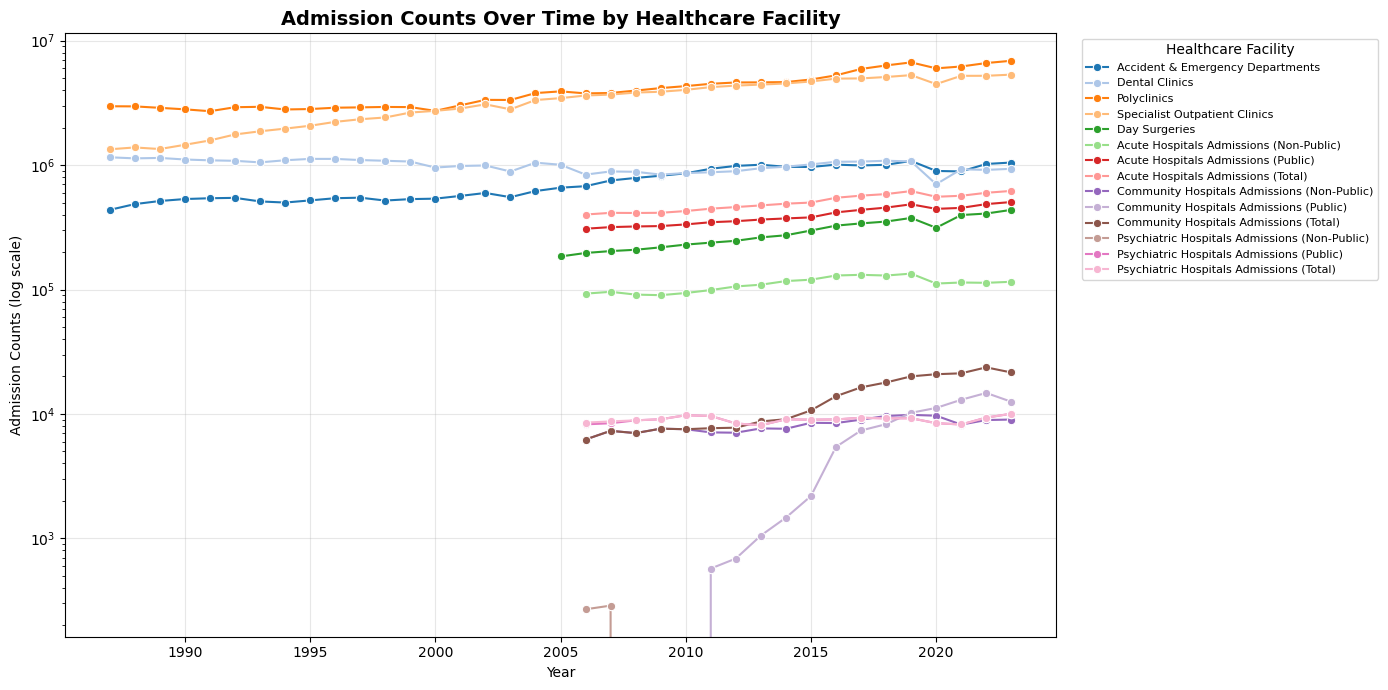

In [55]:
# 1. Admission counts over time per healthcare facility
# Reason: Compare long-term trends, identify crossing between facilities and what it can mean for periods of growth and decline
# Viz: x-axis = Year, y-axis = Admission Counts, Legend = Healthcare facility type

yearly_admissions = (
    healthcare_facilities_df
    .dropna(subset=['Admission Counts'])
    .groupby(['Year', 'Healthcare Facilities'], as_index=False)['Admission Counts']
    .sum()
)

# Line chart of Admission Counts Over Time by Healthcare Facility
plt.figure(figsize=(14, 7))
sns.lineplot(
    data=yearly_admissions,
    x='Year',
    y='Admission Counts',
    hue='Healthcare Facilities',
    palette=sns.color_palette('tab20', n_colors=yearly_admissions['Healthcare Facilities'].nunique()),
    marker='o'
)
plt.title('Admission Counts Over Time by Healthcare Facility', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Admission Counts (log scale)')
plt.yscale('log')  # separates small facilities from large ones
plt.legend(title='Healthcare Facility', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Polyclinics and Specialist Outpatient Clinics have the highest admissions across all years, significantly above all other faciltiies. Both facilities showed an upward trend over the years. Accident & Emergency Departments and Dental Clinics are the next most admitted.

Notably, Community Hospitals Admissions (Public) experienced a sharp increase in admissions from 2011 onwards, highlighting the large variability in admissions.

In [51]:
# 2. Summarize each facility type with average, min, max, median, standard deviation
# Reason: Especially standard deviation where admission counts can vary across years and months
# Viz: Boxplot with IQR

# Printing summary statistics per facility type
summary_stats = (
    healthcare_facilities_df
    .groupby('Healthcare Facilities')['Admission Counts']
    .agg(
        Mean='mean',
        Min='min',
        Max='max',
        Median='median',
        Std_Dev='std'
    )
    .round(2)
    .sort_values('Std_Dev', ascending=False)
)

summary_stats

,Mean,Min,Max,Median,Std_Dev
Healthcare Facilities,,,,,
Specialist Outpatient Clinics,280450.86,94190,513912,284383.5,112051.87
Polyclinics,339633.75,195841,627174,314124.0,111952.47
Dental Clinics,83319.93,8157,123131,86565.5,19076.53
Accident & Emergency Departments,60719.07,33988,98385,55237.5,17912.44
Day Surgeries,24156.86,10393,40448,22702.0,6933.00
Acute Hospitals Admissions (Total),42113.77,29498,54993,41215.0,6581.34
Acute Hospitals Admissions (Public),32887.70,23028,44504,31508.0,5530.81
Acute Hospitals Admissions (Non-Public),9226.06,6470,11968,9237.0,1299.36
Community Hospitals Admissions (Total),1088.07,373,2786,814.5,523.31


Standard deviation increases with mean and median. This is fairly expected especially for Specialist Outpatient Clinics and Polyclinics with high admission volumes.

Community Hospitals Admissions (Public) has a larger standard deviation (447.99) than mean (410.62), which supports the high variability suggested from Chart 1. However, there is a strong right-skew pattern for Community Hospitals (both Total and Public) where mean is above the median, indicating that Community Hospitals show a greater upward trend rather than random variance.

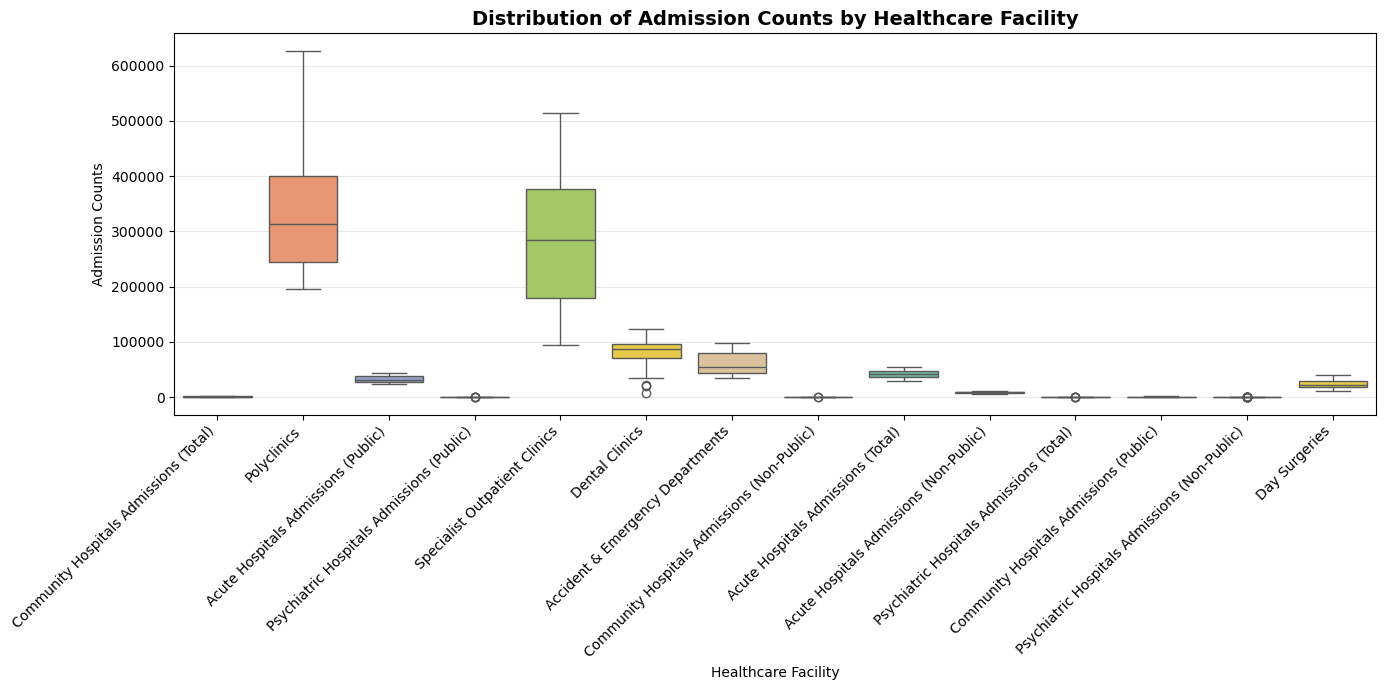

In [53]:
# Displaying the summary stats into a Boxplot
plt.figure(figsize=(14, 7))
sns.boxplot(
    data=healthcare_facilities_df,
    x='Healthcare Facilities',
    y='Admission Counts',
    hue='Healthcare Facilities',
    palette='Set2',
    legend=False
)

plt.title('Distribution of Admission Counts by Healthcare Facility', fontsize=14, fontweight='bold')
plt.xlabel('Healthcare Facility')
plt.ylabel('Admission Counts')
plt.xticks(rotation=45, ha='right')
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

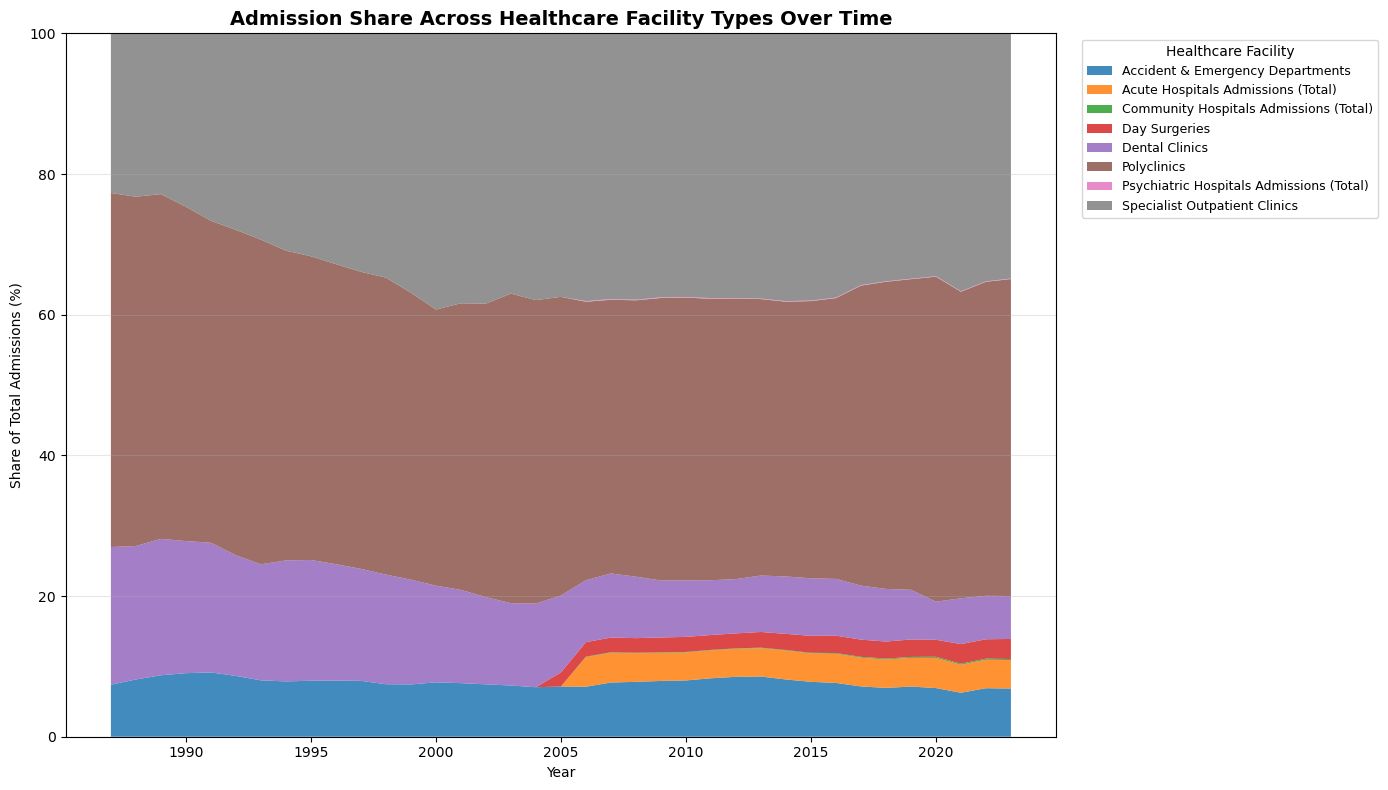

In [56]:
# 3. Admission share across facility types over time
# Reason: Able to see which facilities are becoming relatively more important
# Viz: 100% stacked chart

# Facilities to exclude: the Public/Non-Public breakdowns (keep only Total for these)
exclude_facilities = [
    'Community Hospitals Admissions (Non-Public)',
    'Community Hospitals Admissions (Public)',
    'Acute Hospitals Admissions (Public)',
    'Acute Hospitals Admissions (Non-Public)',
    'Psychiatric Hospitals Admissions (Non-Public)',
    'Psychiatric Hospitals Admissions (Public)',
]

filtered_df = healthcare_facilities_df[
    ~healthcare_facilities_df['Healthcare Facilities'].isin(exclude_facilities)
].copy()

# --- Safety: ensure numeric dtype ---
filtered_df['Admission Counts'] = pd.to_numeric(filtered_df['Admission Counts'], errors='coerce')

# --- Aggregate: sum admission counts per facility per year ---
yearly_admissions = (
    filtered_df
    .dropna(subset=['Admission Counts'])
    .groupby(['Year', 'Healthcare Facilities'], as_index=False)['Admission Counts']
    .sum()
)

# --- Pivot to wide format ---
pivot_df = yearly_admissions.pivot(index='Year', columns='Healthcare Facilities', values='Admission Counts')
pivot_df = pivot_df.fillna(0)

# --- Convert to percentage share per year ---
share_df = pivot_df.div(pivot_df.sum(axis=1), axis=0) * 100

# --- Plot 100% stacked area chart ---
plt.figure(figsize=(14, 8))
plt.stackplot(
    share_df.index,
    share_df.T.values,
    labels=share_df.columns,
    alpha=0.85
)

plt.title('Admission Share Across Healthcare Facility Types Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Share of Total Admissions (%)')
plt.ylim(0, 100)
plt.legend(title='Healthcare Facility', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

### Pending commentary for above graph

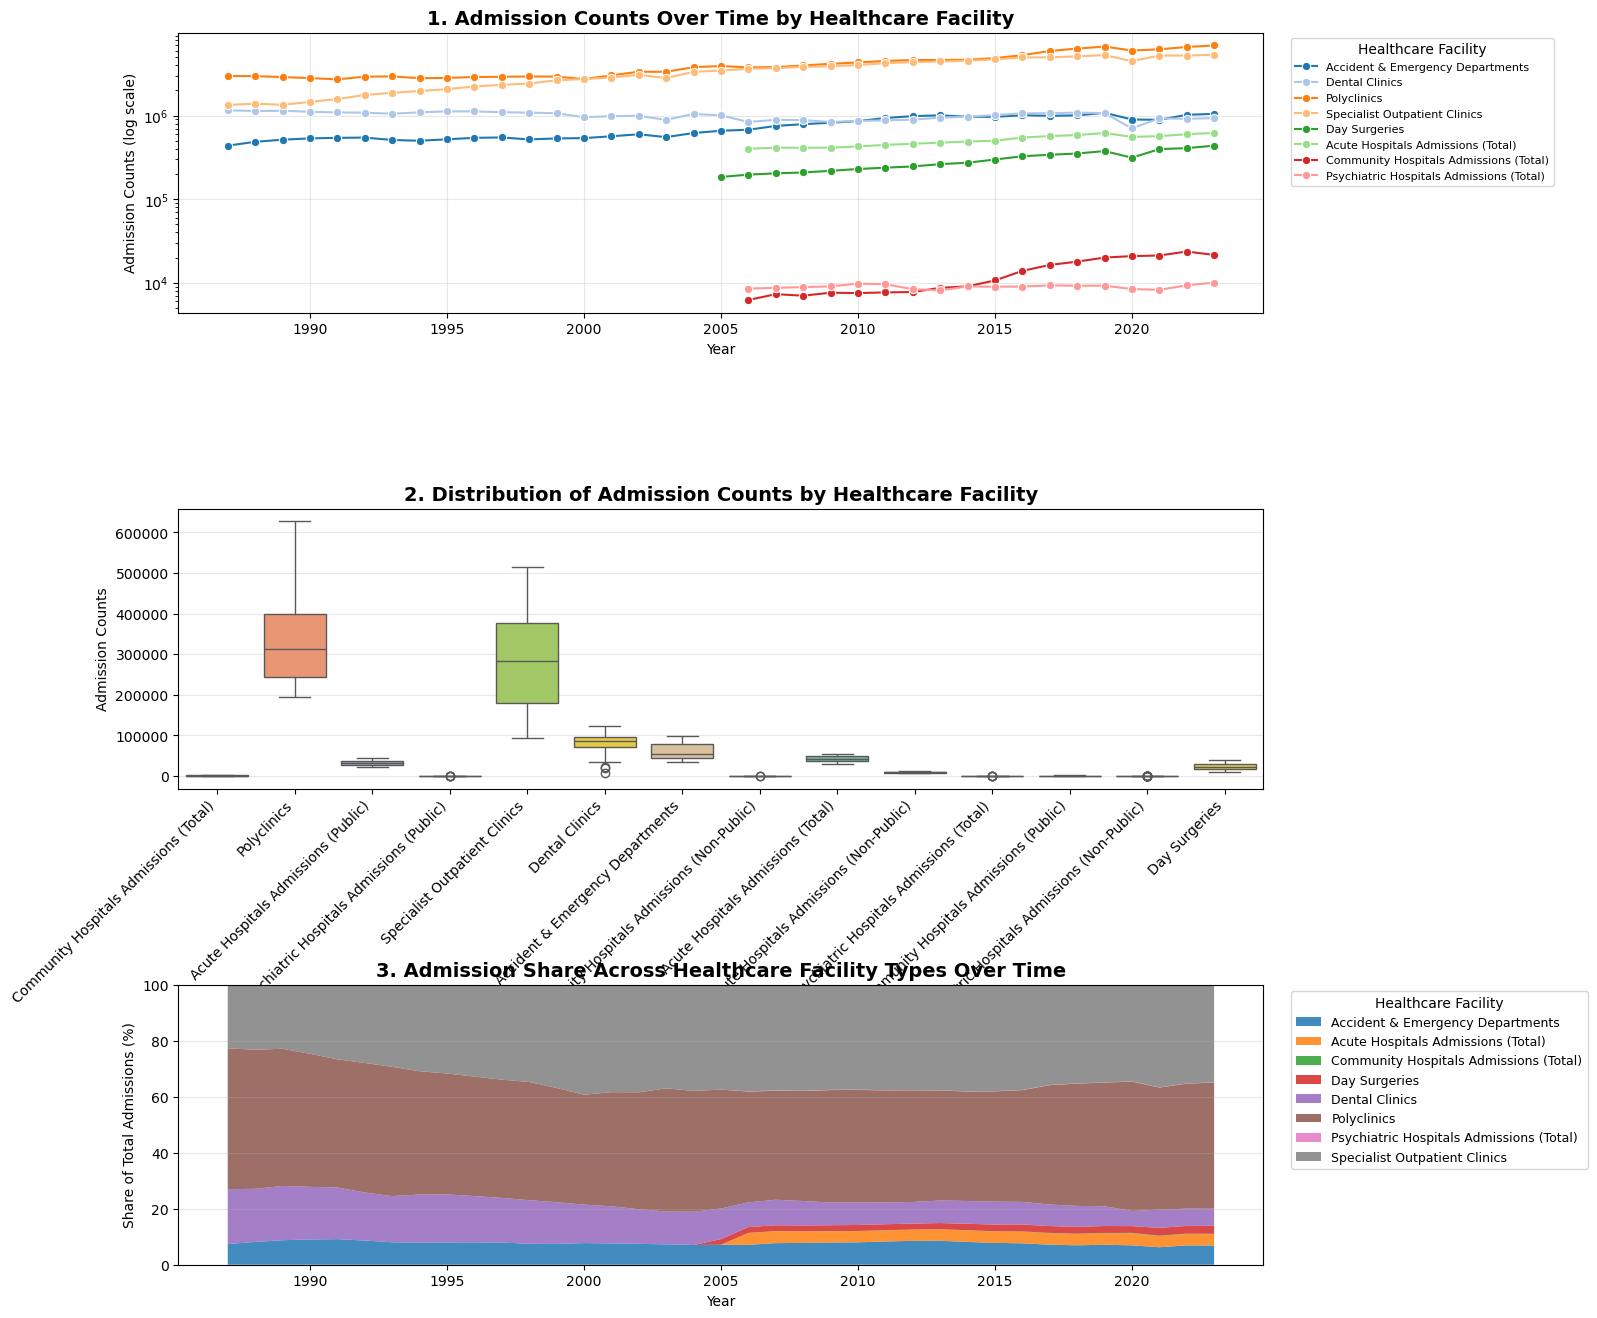

In [64]:
fig, axes = plt.subplots(3, 1, figsize=(14, 16))

# --- Panel 1: Line chart ---
sns.lineplot(
    data=yearly_admissions,
    x='Year',
    y='Admission Counts',
    hue='Healthcare Facilities',
    palette=sns.color_palette('tab20', n_colors=yearly_admissions['Healthcare Facilities'].nunique()),
    marker='o',
    ax=axes[0]
)
axes[0].set_title('1. Admission Counts Over Time by Healthcare Facility', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Admission Counts (log scale)')
axes[0].set_yscale('log')
axes[0].legend(title='Healthcare Facility', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
axes[0].grid(alpha=0.3)

# --- Panel 2: Boxplot ---
sns.boxplot(
    data=healthcare_facilities_df,
    x='Healthcare Facilities',
    y='Admission Counts',
    hue='Healthcare Facilities',
    palette='Set2',
    legend=False,
    ax=axes[1]
)
axes[1].set_title('2. Distribution of Admission Counts by Healthcare Facility', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Healthcare Facility')
axes[1].set_ylabel('Admission Counts')
axes[1].tick_params(axis='x', rotation=45)
for label in axes[1].get_xticklabels():
    label.set_ha('right')
axes[1].grid(alpha=0.3, axis='y')

# --- Panel 3: 100% stacked area chart ---
axes[2].stackplot(
    share_df.index,
    share_df.T.values,
    labels=share_df.columns,
    alpha=0.85
)
axes[2].set_title('3. Admission Share Across Healthcare Facility Types Over Time', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Year')
axes[2].set_ylabel('Share of Total Admissions (%)')
axes[2].set_ylim(0, 100)
axes[2].legend(title='Healthcare Facility', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
axes[2].grid(alpha=0.3, axis='y')

plt.subplots_adjust(hspace=0.7)
plt.show()

#### Hospital Admission Rate by Gender and Age

In [16]:
# Basic EDA
# 1. Admission rate by gender over time
# Reason: Trends in sex-specific healthcare demand that is easy to communicate. See if any significant shifts that communicate demand changes
# Viz: Line chart. x-axis = Year, y-axis = Admission rate, Legend = Gender

# 2. Admission rate by age over time
# Reason: Age is strongest driver of admission rates. Able to see which age segments generate the highest burden and whether rates change within groups over time
# Viz: Line chart. x-axis = Year, y-axis = Admission rate, Legend = Age group

# 3. Admission rate by hospital type by age group
# Reason: Hospital utilization differs more strongly by age than by gender, espcailly when comparing acute, community and psychiatric settings
# Viz: Clustered bar chart. x-axis: Hospital Type, y-axis: Admission Rate, Hue: Age Group

#### Prevalence of Health Indicators for SG adults

In [ ]:
# Basic EDA
# 1. Healthy Behavior vs risk factors over time
# Reason: Observe population health against risk factors, whether healthier behavior moves opposite to risk factors over time
# Viz: Line chart. x-axis = Year, y-axis = Proportion, Legend = risk factors + Sufficient Total Physical Activity

# 2. Male vs Female by risk factor 
# Reason: Uncover gender differences between risk factors
# Viz: Grouped bar chart. x-axis = Risk Factor, y-axis = Proportion, hue = Gender